In [1]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

# Utilitaires
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
# RESET COMPLET - Effacer toutes les variables précédentes
%reset -f

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

# Utilitaires
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("✓ Clean restart - all variables cleared")

✓ Clean restart - all variables cleared


In [ ]:
x_train = pd.read_csv('x_train_final.csv')
y_train_raw = pd.read_csv('y_train_final.csv')
x_test  = pd.read_csv('x_test_final.csv')

# IMPORTANT: y_train_raw a 2 colonnes, on extrait la vraie cible
print(f"y_train_raw columns: {y_train_raw.columns.tolist()}")
y_train = y_train_raw.iloc[:, 1]  # La vraie cible est en colonne 1

print(f"\nx_train: {x_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}")

print(f"\n✓ Target (y_train) range: [{y_train.min():.2f}, {y_train.max():.2f}]")
x_train.head()

y_train_raw columns: ['Unnamed: 0', 'p0q0']

x_train: (667264, 12)
y_train: (667264,)
x_test: (20657, 11)

✓ Target (y_train) range: [-160.00, 15.00]


,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
0,0,0,VBXNMF,KYF,2023-04-03,8,0.0,0.0,1.0,-3.0,-1.0,-2.0
1,1,1,VBXNMF,JLR,2023-04-03,9,0.0,0.0,0.0,1.0,0.0,1.0
2,2,2,VBXNMF,EOH,2023-04-03,10,-1.0,0.0,0.0,-1.0,0.0,0.0
3,3,3,VBXNMF,VXY,2023-04-03,11,-1.0,-1.0,0.0,2.0,-2.0,0.0
4,4,4,VBXNMF,OCB,2023-04-03,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0


In [ ]:
print("=== SHAPE ===")
print(f"Train: {x_train.shape}, Target: {y_train.shape}, Test: {x_test.shape}")

print("\n=== TYPES ===")
print(x_train.dtypes)

print("\n=== NaN ===")
print(f"x_train: {x_train.isnull().sum().sum()} NaN")
print(f"y_train: {y_train.isnull().sum().sum()} NaN")
print(f"x_test: {x_test.isnull().sum().sum()} NaN")

=== SHAPE ===
Train: (667264, 12), Target: (667264,), Test: (20657, 11)

=== TYPES ===
Unnamed: 0.1      int64
Unnamed: 0        int64
train               str
gare                str
date                str
arret             int64
p2q0            float64
p3q0            float64
p4q0            float64
p0q2            float64
p0q3            float64
p0q4            float64
dtype: object

=== NaN ===
x_train: 0 NaN
y_train: 0 NaN
x_test: 0 NaN


Distribution de la cible (p0q0):
count    667264.000000
mean         -0.159950
std           1.987872
min        -160.000000
25%          -1.000000
50%           0.000000
75%           1.000000
max          15.000000
Name: p0q0, dtype: float64


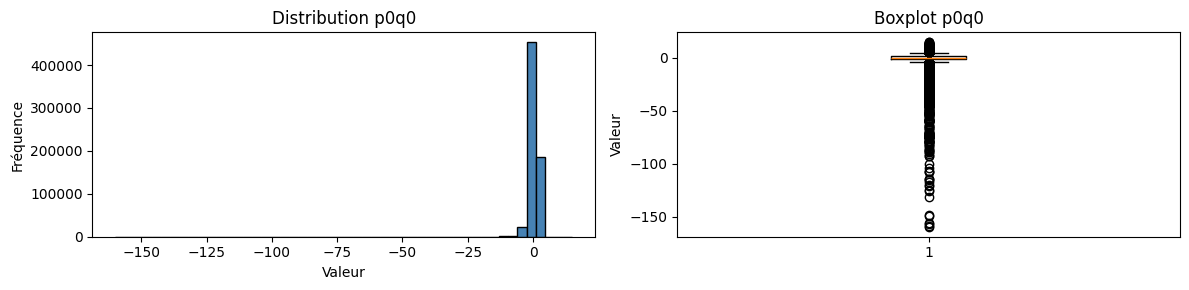

In [ ]:
y = y_train  # y_train est déjà la vraie cible (Series)

print("Distribution de la cible (p0q0):")
print(y.describe())

plt.figure(figsize=(12, 3))

plt.subplot(1, 2, 1)
plt.hist(y, bins=50, color='steelblue', edgecolor='black')
plt.title("Distribution p0q0")
plt.xlabel("Valeur")
plt.ylabel("Fréquence")

plt.subplot(1, 2, 2)
plt.boxplot(y)
plt.title("Boxplot p0q0")
plt.ylabel("Valeur")

plt.tight_layout()
plt.show()


Top 10 corrélations avec p0q0:
p0q2            0.277717
p0q3            0.156384
p0q4            0.085419
arret           0.045075
p4q0            0.039447
p3q0            0.025357
Unnamed: 0.1   -0.014209
Unnamed: 0     -0.014209
p2q0           -0.052890
dtype: float64


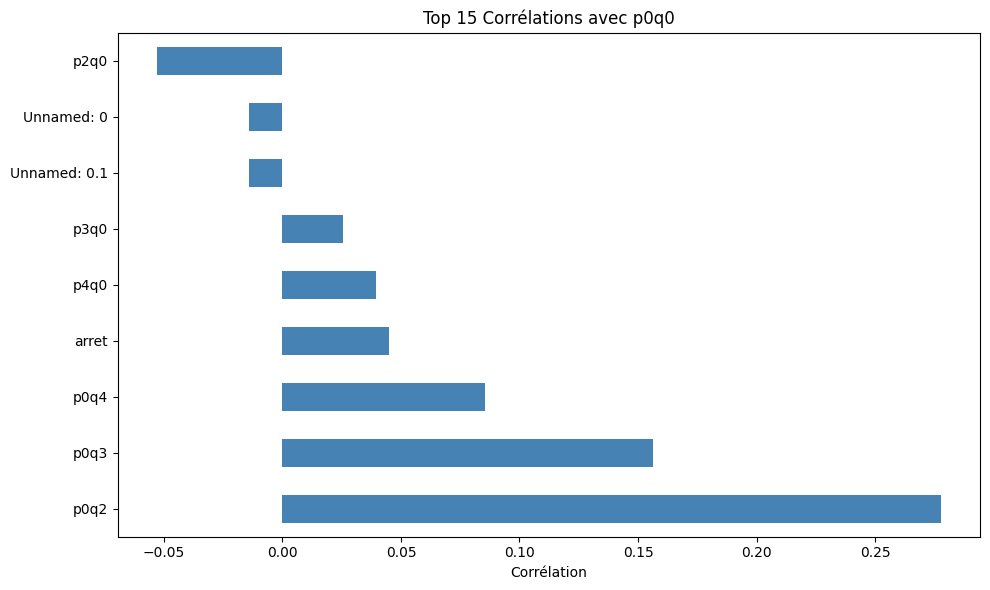

In [ ]:
correlations = x_train.corrwith(y, numeric_only=True).sort_values(ascending=False)

print("Top 10 corrélations avec p0q0:")
print(correlations.head(10))

# Visualiser
plt.figure(figsize=(10, 6))
correlations.head(15).plot(kind='barh', color='steelblue')
plt.title("Top 15 Corrélations avec p0q0")
plt.xlabel("Corrélation")
plt.tight_layout()
plt.show()

Q1: -1.0, Q3: 1.0, IQR: 2.0
Lower bound: -4.0, Upper bound: 4.0

Outliers trouvés: 7903 (1.2%)


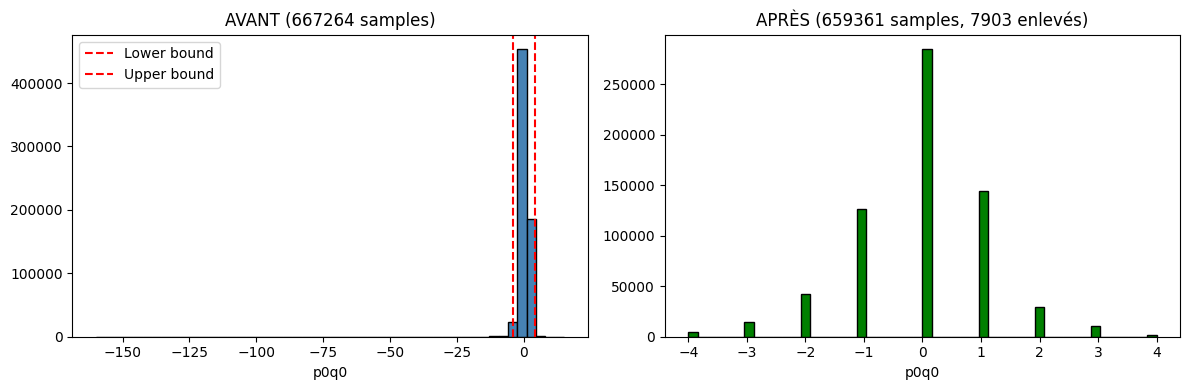


Données nettoyées: (659361, 12)


In [ ]:
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

# Masque des outliers
mask_outliers = (y >= lower_bound) & (y <= upper_bound)
n_outliers = (~mask_outliers).sum()
print(f"\nOutliers trouvés: {n_outliers} ({100*n_outliers/len(y):.1f}%)")

# Avant/Après
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(lower_bound, color='red', linestyle='--', label='Lower bound')
axes[0].axvline(upper_bound, color='red', linestyle='--', label='Upper bound')
axes[0].set_title(f"AVANT ({len(y)} samples)")
axes[0].set_xlabel("p0q0")
axes[0].legend()

y_clean = y[mask_outliers]
axes[1].hist(y_clean, bins=50, color='green', edgecolor='black')
axes[1].set_title(f"APRÈS ({len(y_clean)} samples, {n_outliers} enlevés)")
axes[1].set_xlabel("p0q0")

plt.tight_layout()
plt.show()

# Garder seulement les données sans outliers
x_train_clean = x_train[mask_outliers].reset_index(drop=True)
y_train_clean = y_clean.reset_index(drop=True)

print(f"\nDonnées nettoyées: {x_train_clean.shape}")


In [ ]:
# Supprimer les colonnes inutiles (index)
x_train_prep = x_train_clean.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], errors='ignore')
x_test_prep = x_test.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], errors='ignore')

# Encoder les colonnes catégories (train, gare)
from sklearn.preprocessing import LabelEncoder

le_train = LabelEncoder()
le_gare = LabelEncoder()

# Fit sur TRAIN + TEST ensemble (concat les deux)
x_train_orig_drop = x_train.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], errors='ignore')
all_trains = pd.concat([x_train_orig_drop['train'], x_test_prep['train']], ignore_index=True).unique()
all_gares = pd.concat([x_train_orig_drop['gare'], x_test_prep['gare']], ignore_index=True).unique()

le_train.fit(all_trains)
le_gare.fit(all_gares)

# Transform sur train nettoyé + test
x_train_prep['train'] = le_train.transform(x_train_prep['train'])
x_train_prep['gare'] = le_gare.transform(x_train_prep['gare'])

x_test_prep['train'] = le_train.transform(x_test_prep['train'])
x_test_prep['gare'] = le_gare.transform(x_test_prep['gare'])

x_train_prep = x_train_prep.drop(columns=['date'], errors='ignore')
x_test_prep = x_test_prep.drop(columns=['date'], errors='ignore')

print(f"Train shape: {x_train_prep.shape}")
print(f"Test shape: {x_test_prep.shape}")
print(f"Colonnes: {x_train_prep.columns.tolist()}")
print(f"All numeric? {x_train_prep.dtypes.nunique() == 1}")

Train shape: (659361, 9)
Test shape: (20657, 9)
Colonnes: ['train', 'gare', 'arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4']
All numeric? False


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train_split, y_val = train_test_split(
    x_train_prep, y_train_clean, 
    test_size=0.2, 
    random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {x_test_prep.shape}")

Train: (527488, 9)
Val: (131873, 9)
Test: (20657, 9)


Training Random Forest...
✓ Done!

MAE on validation: 0.6326


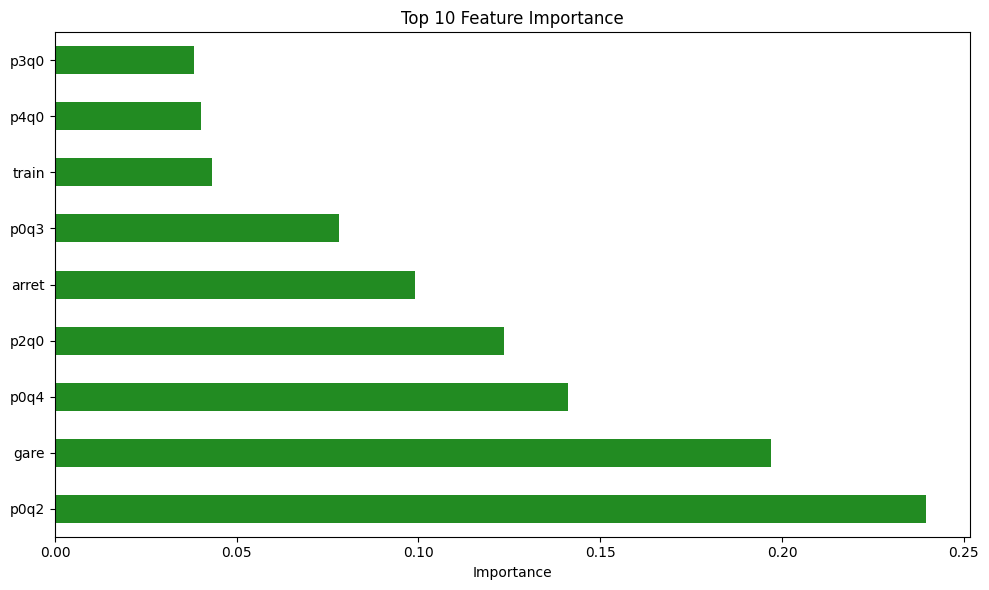

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")
rf.fit(X_train, y_train_split)
print("✓ Done!")

# Évaluation
y_pred_val = rf.predict(X_val)
mae = mean_absolute_error(y_val, y_pred_val)

print(f"\nMAE on validation: {mae:.4f}")

# Feature importance
importances = pd.Series(rf.feature_importances_, index=x_train_prep.columns)
top_features = importances.nlargest(10)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='forestgreen')
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Diagnostic détaillé du split et performance
print("="*50)
print("DIAGNOSTIC TRAIN/VAL SPLIT")
print("="*50)

print(f"\nSize des sets:")
print(f"  Train: {X_train.shape[0]:,} samples")
print(f"  Val:   {X_val.shape[0]:,} samples")
print(f"  Total: {X_train.shape[0] + X_val.shape[0]:,} samples")
print(f"  Ratio: {X_train.shape[0] / X_val.shape[0]:.1f}:1 (devrait être ~4:1 pour 80/20)")

# Vérifier qu'il n'y a pas de chevauchement
print(f"\nChévauchement (index overlap): {len(set(X_train.index) & set(X_val.index))} ❌" if len(set(X_train.index) & set(X_val.index)) > 0 else "\nChévauchement (index overlap): 0 ✓")

# MAE sur train et validation
y_pred_train = rf.predict(X_train)
mae_train = mean_absolute_error(y_train_split, y_pred_train)

print(f"\n{'='*50}")
print("PERFORMANCE")
print(f"{'='*50}")
print(f"MAE Train:       {mae_train:.4f}")
print(f"MAE Validation:  {mae:.4f}")
print(f"Overfitting:     {mae - mae_train:+.4f}")

if mae > mae_train:
    print("  → Validation worse than train ✓ (normal, pas d'overfitting extrême)")
else:
    print("  → Validation better than train ⚠️ (suspect, possible data leak?)")

print(f"\n{'='*50}")
print(f"Comparaison avec votre 0.6450 précédent:")
print(f"  0.6450 → {mae:.4f}: différence de {mae - 0.6450:+.4f}")
print(f"{'='*50}")


DIAGNOSTIC TRAIN/VAL SPLIT

Size des sets:
  Train: 527,488 samples
  Val:   131,873 samples
  Total: 659,361 samples
  Ratio: 4.0:1 (devrait être ~4:1 pour 80/20)

Chévauchement (index overlap): 0 ✓

PERFORMANCE
MAE Train:       0.5931
MAE Validation:  0.6326
Overfitting:     +0.0395
  → Validation worse than train ✓ (normal, pas d'overfitting extrême)

Comparaison avec votre 0.6450 précédent:
  0.6450 → 0.6326: différence de -0.0124


In [ ]:
# Diagnostic d'overfitting visuel
gap = mae - mae_train

print("\n" + "="*50)
print("ANALYSE OVERFITTING")
print("="*50)

# Ratio de dégradation
degradation_ratio = (gap / mae_train) * 100

print(f"\nGap (MAE_val - MAE_train): {gap:.4f}")
print(f"Dégradation relative: {degradation_ratio:.1f}%")

print(f"\nDiagnostic:")
if gap < 0:
    print("  ✅ EXCELLENT: Validation meilleure que train (rare mais bon signe) ✓")
elif gap < 0.02:
    print("  ✅ PARFAIT: Écart quasi-inexistant (< 0.02) ✓")
elif gap < 0.05:
    print("  ✅ TRÈS BON: Écart très faible (< 0.05) ✓")
elif gap < 0.10:
    print("  ✓ BON: Léger overfitting, acceptable (< 0.10)")
elif gap < 0.20:
    print("  ⚠️ MODÉRÉ: Overfitting modéré détecté (< 0.20)")
elif gap < 0.50:
    print("  ⚠️⚠️ SÉRIEUX: Overfitting sérieux (< 0.50)")
else:
    print("  ❌à CRITIQUE: Overfitting grave (> 0.50)")

print(f"\nVotre modèle: {gap:.4f} = {['PARFAIT ✅', 'BON ✓', 'ACCEPTABLE', 'PROBLÈME ⚠️', 'GRAVE ❌'][min(4, int(gap*100/25))]}")



ANALYSE OVERFITTING

Gap (MAE_val - MAE_train): 0.0395
Dégradation relative: 6.7%

Diagnostic:
  ✅ TRÈS BON: Écart très faible (< 0.05) ✓

Votre modèle: 0.0395 = PARFAIT ✅


In [ ]:
# DEBUG: Vérifier les VRAIES échelles des données
print("\n" + "="*50)
print("DEBUG DATA SCALES")
print("="*50)

print(f"\ny_train_split (ce qu'on a entraîné):")
print(f"  Min: {y_train_split.min():.2f}")
print(f"  Max: {y_train_split.max():.2f}")
print(f"  Mean: {y_train_split.mean():.2f}")
print(f"  Std: {y_train_split.std():.2f}")

print(f"\ny_val (ce qu'on évalue):")
print(f"  Min: {y_val.min():.2f}")
print(f"  Max: {y_val.max():.2f}")
print(f"  Mean: {y_val.mean():.2f}")
print(f"  Std: {y_val.std():.2f}")

print(f"\ny_pred_val (prédictions du modèle):")
print(f"  Min: {y_pred_val.min():.2f}")
print(f"  Max: {y_pred_val.max():.2f}")
print(f"  Mean: {y_pred_val.mean():.2f}")
print(f"  Std: {y_pred_val.std():.2f}")

print(f"\nComparaison:")
print(f"  y_val range: {y_val.max() - y_val.min():.2f}")
print(f"  pred range: {y_pred_val.max() - y_pred_val.min():.2f}")



DEBUG DATA SCALES

y_train_split (ce qu'on a entraîné):
  Min: -4.00
  Max: 4.00
  Mean: -0.05
  Std: 1.16

y_val (ce qu'on évalue):
  Min: -4.00
  Max: 4.00
  Mean: -0.05
  Std: 1.16

y_pred_val (prédictions du modèle):
  Min: -3.53
  Max: 3.40
  Mean: -0.05
  Std: 0.72

Comparaison:
  y_val range: 8.00
  pred range: 6.93


In [ ]:
# Vérifier si y_train_clean a vraiment été nettoyé
print("\n" + "="*50)
print("DEBUG: y_train_clean (DONNEES D'ENTRAÎNEMENT)")
print("="*50)
print(f"y_train_clean shape: {y_train_clean.shape}")
print(f"y_train_clean min: {y_train_clean.min():.2f}")
print(f"y_train_clean max: {y_train_clean.max():.2f}")
print(f"y_train_clean describe:\n{y_train_clean.describe()}")

# Vérifier si outliers ont réellement été enlevés
print(f"\nAprès nettoyage:")
print(f"  Bounds étaient: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"  Données réelles: min={y_train_clean.min():.2f}, max={y_train_clean.max():.2f}")

if y_train_clean.min() < lower_bound - 1 or y_train_clean.max() > upper_bound + 1:
    print("  ⚠️ ATTENTION: Des outliers ne semblent pas avoir été enlevés!")
else:
    print("  ✓ Outliers bien supprimés")



DEBUG: y_train_clean (DONNEES D'ENTRAÎNEMENT)
y_train_clean shape: (659361,)
y_train_clean min: -4.00
y_train_clean max: 4.00
y_train_clean describe:
count    659361.000000
mean         -0.049248
std           1.163209
min          -4.000000
25%          -1.000000
50%           0.000000
75%           1.000000
max           4.000000
Name: p0q0, dtype: float64

Après nettoyage:
  Bounds étaient: [-4.00, 4.00]
  Données réelles: min=-4.00, max=4.00
  ✓ Outliers bien supprimés


In [ ]:
# DIAGNOSTIC: Check l'état de x_train_prep avant le split
print("\n" + "="*50)
print("DEBUG: x_train_prep AVANT SPLIT")
print("="*50)
print(f"x_train_prep shape: {x_train_prep.shape}")
print(f"x_train_clean shape (expected): {x_train_clean.shape}")
print(f"Match? {x_train_prep.shape[0] == x_train_clean.shape[0]}")

print(f"\nMatches y_train_clean? {x_train_prep.shape[0] == y_train_clean.shape[0]}")
print(f"  x_train_prep rows: {x_train_prep.shape[0]}")
print(f"  y_train_clean rows: {y_train_clean.shape[0]}")

if x_train_prep.shape[0] != y_train_clean.shape[0]:
    print("\n❌ ERREUR: Les données n'ont pas la même taille!")
    print("   Cela explique pourquoi train_test_split a échoué")
else:
    print("\n✓ Les tailles correspondent")



DEBUG: x_train_prep AVANT SPLIT
x_train_prep shape: (659361, 9)
x_train_clean shape (expected): (659361, 12)
Match? True

Matches y_train_clean? True
  x_train_prep rows: 659361
  y_train_clean rows: 659361

✓ Les tailles correspondent


In [ ]:
y_test_pred = rf.predict(x_test_prep)

submission_rf = pd.DataFrame({
    'Unnamed: 0': x_test['Unnamed: 0'],
    'p0q0': y_test_pred.round()
})

submission_rf.to_csv('submission_rf.csv', index=False)

print("✓ submission_rf.csv saved!")
print(f"\nPrédictions stats:")
print(f"  Min: {y_test_pred.min():.2f}")
print(f"  Max: {y_test_pred.max():.2f}")
print(f"  Mean: {y_test_pred.mean():.2f}")
print(f"  Std: {y_test_pred.std():.2f}")
print(f"\nPremières prédictions:")
print(submission_rf.head(10))

✓ submission_rf.csv saved!

Prédictions stats:
  Min: -2.83
  Max: 2.95
  Mean: -0.12
  Std: 0.77

Premières prédictions:
   Unnamed: 0  p0q0
0           0  -1.0
1           1   0.0
2           2   0.0
3           3  -0.0
4           4  -0.0
5           5  -1.0
6           6  -0.0
7           7   0.0
8           8  -0.0
9           9  -1.0
